# Artificial Neural Network (ANN) - 
## Multi-Class Classification using PyTorch

#### optimization(batch_normalization, dropout , L1/l2 regularization)


---

## 1. Setup & Imports

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
torch.cuda.empty_cache()
# Set seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---

## 2. Load & Explore Data

In [98]:
# Load MNIST data
df = pd.read_csv('/home/saif/Desktop/pytorch/fmnist_small.csv')

print("📊 Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nColumns: label + {df.shape[1] - 1} pixels (28x28 image)")
print(f"\nFirst few rows:")
df.head()

📊 Dataset Overview:
Shape: (6000, 785)

Columns: label + 784 pixels (28x28 image)

First few rows:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


📊 Class Distribution:
label
0    595
1    590
2    604
3    591
4    595
5    612
6    656
7    620
8    582
9    555
Name: count, dtype: int64


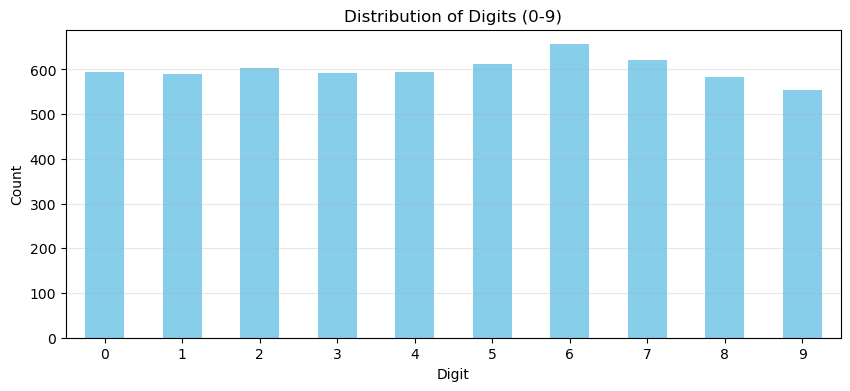

In [99]:
# Class distribution
print("📊 Class Distribution:")
print(df['label'].value_counts().sort_index())

# Visualize
plt.figure(figsize=(10, 4))
df['label'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits (0-9)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

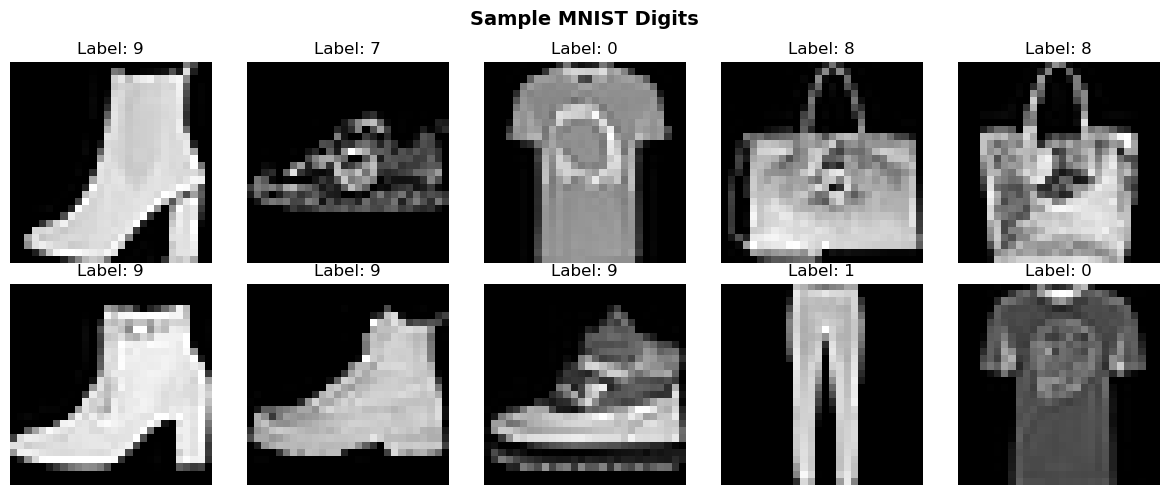

In [100]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Get image and label
    img = df.iloc[i, 1:].values.reshape(28, 28)
    label = df.iloc[i, 0]
    
    # Display
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## 3. Prepare Data

In [101]:
# Separate features and labels
X = df.drop('label', axis=1).values  # Pixels
y = df['label'].values                # Labels (0-9)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nPixel values range: [{X.min()}, {X.max()}]")
print(f"Unique labels: {np.unique(y)}")

Features shape: (6000, 784)
Labels shape: (6000,)

Pixel values range: [0, 255]
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [102]:
# Normalize pixel values to [0, 1]
X = X / 255.0

print(f"After normalization: [{X.min():.2f}, {X.max():.2f}]")
print(f"Mean: {X.mean():.4f}, Std: {X.std():.4f}")

After normalization: [0.00, 1.00]
Mean: 0.2867, Std: 0.3528


In [103]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" Data Split:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

 Data Split:
Train: 4800 samples
Test: 1200 samples


---

## 4. Create Dataset & DataLoader

In [104]:
class MNISTDataset(Dataset):
    """
    Custom Dataset for MNIST data
    """
    def __init__(self, features, labels):
        # Convert to tensors with correct dtype
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)  # LongTensor for classification!
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset = MNISTDataset(X_train, y_train)
test_dataset = MNISTDataset(X_test, y_test)

print(" Datasets created")
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

 Datasets created
Train dataset: 4800 samples
Test dataset: 1200 samples


In [105]:
# Create DataLoaders
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,pin_memory=True
)

print(" DataLoaders created")
print(f"Train: {len(train_loader)} batches of size {batch_size}")
print(f"Test: {len(test_loader)} batches of size {batch_size}")

 DataLoaders created
Train: 75 batches of size 64
Test: 19 batches of size 64


---

## 5. Define Model

In [106]:
class DigitClassifier(nn.Module):
    """
    Neural Network for MNIST Digit Classification
    
    Architecture:
    Input (784) → FC(128) → ReLU → FC(64) → ReLU → FC(10)
    """
    def __init__(self, input_size=784, hidden1=128, hidden2=64,hidden3 = 32, num_classes=10):
        super(DigitClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(hidden2, hidden3),
            nn.BatchNorm1d(hidden3),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(hidden3, num_classes)
            # No softmax here! CrossEntropyLoss includes it
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
model = DigitClassifier().to(device)

print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Model Architecture:
DigitClassifier(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=10, bias=True)
  )
)

Total parameters: 111,594


---

## 6. Training Setup

In [107]:
# Hyperparameters
num_epochs = 50
learning_rate = 0.01  # 0.1 is too high!

# Loss function (for multi-class classification)
criterion = nn.CrossEntropyLoss()  # NOT BCELoss!

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=1e-4)  # Adam better than SGD

print("Training Configuration:")
print(f"Epochs: {num_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batch_size}")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}")

Training Configuration:
Epochs: 50
Learning rate: 0.01
Batch size: 64
Loss function: CrossEntropyLoss()
Optimizer: Adam


---

## 7. Training & Evaluation Functions

In [108]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for features, labels in train_loader:
        # Move to device
        features = features.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def evaluate(model, test_loader, criterion, device):
    """Evaluate on test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

print("✅ Training functions defined")

✅ Training functions defined


---

## 8. Train the Model

In [109]:
# Track metrics
train_losses = []
train_accs = []
test_losses = []
test_accs = []

print(" Starting training...\n")
print("Epoch | Train Loss | Train Acc | Test Loss | Test Acc")
print("-" * 60)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    # Store
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_acc:9.4f} | "
              f"{test_loss:9.4f} | {test_acc:8.4f}")

print("\n Training completed!")
print(f"\nFinal Results:")
print(f"  Train Accuracy: {train_accs[-1]*100:.2f}%")
print(f"  Test Accuracy: {test_accs[-1]*100:.2f}%")

 Starting training...

Epoch | Train Loss | Train Acc | Test Loss | Test Acc
------------------------------------------------------------
    1 |     1.1360 |    0.6038 |    0.6504 |   0.7483
    5 |     0.6392 |    0.7792 |    0.4938 |   0.8233
   10 |     0.5330 |    0.8098 |    0.4782 |   0.8192
   15 |     0.4916 |    0.8310 |    0.4524 |   0.8350
   20 |     0.4910 |    0.8263 |    0.4322 |   0.8367
   25 |     0.4603 |    0.8408 |    0.4477 |   0.8392
   30 |     0.4710 |    0.8331 |    0.4472 |   0.8375
   35 |     0.4642 |    0.8410 |    0.4651 |   0.8367
   40 |     0.4681 |    0.8373 |    0.4830 |   0.8200
   45 |     0.4653 |    0.8350 |    0.5221 |   0.8008
   50 |     0.4530 |    0.8348 |    0.4653 |   0.8375

 Training completed!

Final Results:
  Train Accuracy: 83.48%
  Test Accuracy: 83.75%


---

## 9. Visualize Training

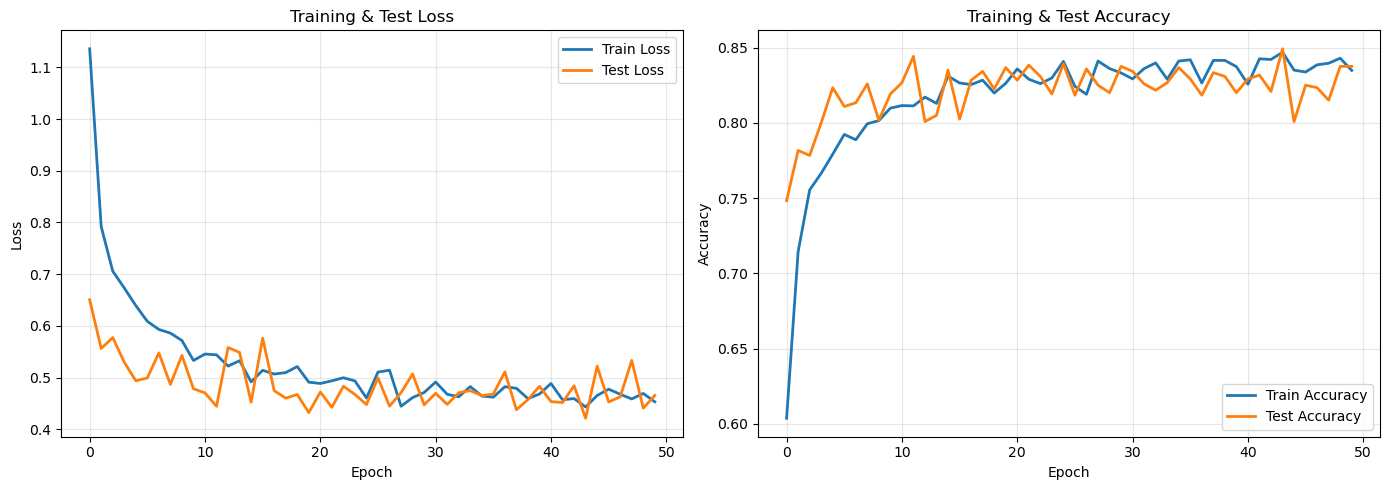

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 10. Model Evaluation

In [111]:
# Get all predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [112]:
# Classification report
print("📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, 
                          target_names=[str(i) for i in range(10)]))

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.95      0.77       119
           1       0.99      0.97      0.98       118
           2       0.75      0.80      0.77       121
           3       0.96      0.82      0.89       118
           4       0.73      0.70      0.72       119
           5       0.98      0.88      0.93       123
           6       0.64      0.45      0.53       131
           7       0.97      0.91      0.94       124
           8       0.94      0.95      0.94       116
           9       0.84      0.99      0.91       111

    accuracy                           0.84      1200
   macro avg       0.85      0.84      0.84      1200
weighted avg       0.84      0.84      0.83      1200



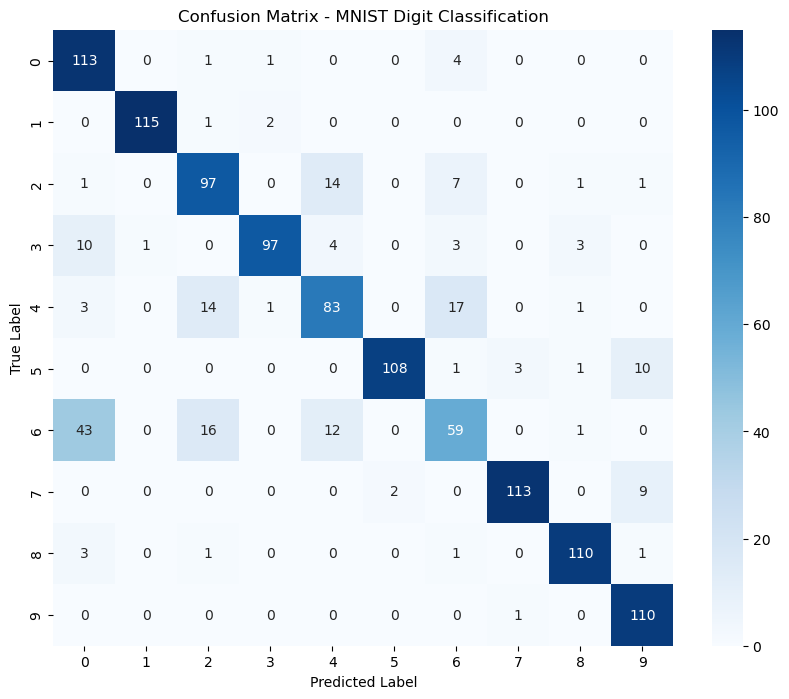


📈 Per-class Accuracy:
Digit 0: 94.96%
Digit 1: 97.46%
Digit 2: 80.17%
Digit 3: 82.20%
Digit 4: 69.75%
Digit 5: 87.80%
Digit 6: 45.04%
Digit 7: 91.13%
Digit 8: 94.83%
Digit 9: 99.10%


In [113]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - MNIST Digit Classification')
plt.show()

print("\n📈 Per-class Accuracy:")
for i in range(10):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"Digit {i}: {class_acc:.2f}%")

---

## 11. Test on Sample Images

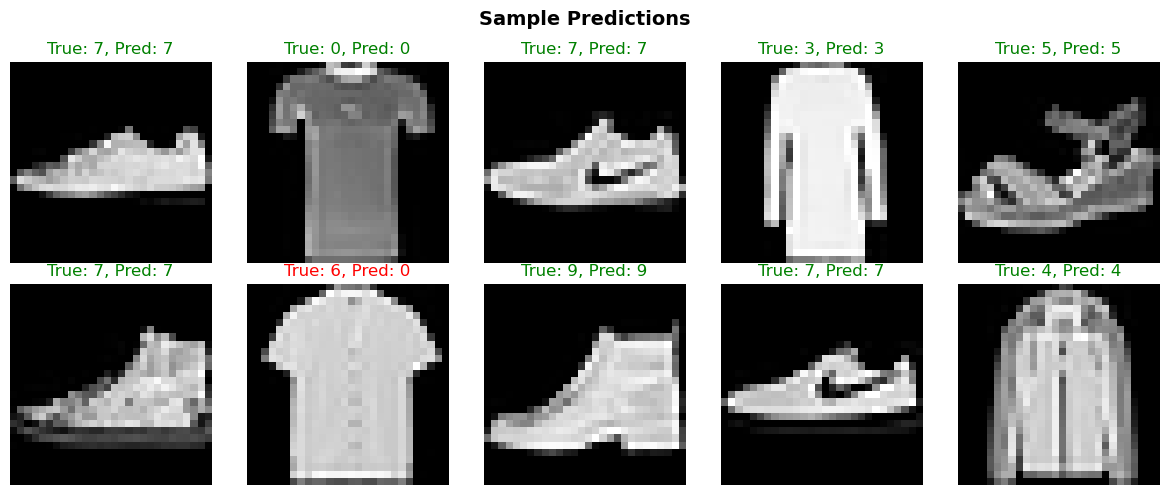

In [114]:
# Visualize predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Predictions', fontsize=14, fontweight='bold')

# Get 10 random test samples
indices = np.random.choice(len(X_test), 10, replace=False)

model.eval()
with torch.no_grad():
    for idx, ax in enumerate(axes.flat):
        # Get image
        img = X_test[indices[idx]].reshape(28, 28)
        true_label = y_test[indices[idx]]
        
        # Predict
        img_tensor = torch.FloatTensor(X_test[indices[idx]]).unsqueeze(0).to(device)
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
        pred_label = predicted.item()
        
        # Display
        ax.imshow(img, cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'True: {true_label}, Pred: {pred_label}', color=color)
        ax.axis('off')

plt.tight_layout()
plt.show()

---

## 12. Save Model

In [115]:
# Save model
torch.save(model.state_dict(), 'mnist_digit_classifier.pth')
print("Model saved to 'mnist_digit_classifier.pth'")

# Save complete checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'test_accs': test_accs,
    'final_test_acc': test_accs[-1]
}
torch.save(checkpoint, 'mnist_checkpoint.pth')
print(" Checkpoint saved to 'mnist_checkpoint.pth'")

Model saved to 'mnist_digit_classifier.pth'
 Checkpoint saved to 'mnist_checkpoint.pth'
